<a href="https://colab.research.google.com/github/white-I-I/ML--experiments-/blob/main/Ex_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['Opal', 'Colab Notebooks', 'Colab', 'Drive']

In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Opal', 'Colab Notebooks', 'Colab', 'Drive']


DECISION TREE CLASSIFICATION PROJECT - EX_8_25

Dataset Loaded Successfully!

Dataset Shape:
(200, 7)

First 5 Rows:
   CGPA     IQ  Aptitude_Score  Communication_Skill  Internships Branch Placed
0  8.00   81.0            89.0                    1            1   MECH     No
1  7.36  105.0            74.0                    5            3  CIVIL    Yes
2  8.15   96.0            62.0                    6            1     IT     No
3  9.02  119.0            56.0                    6            2    CSE     No
4   NaN    NaN             NaN                    3            3    CSE    Yes

DATASET INFORMATION

Column Names:
['CGPA', 'IQ', 'Aptitude_Score', 'Communication_Skill', 'Internships', 'Branch', 'Placed']

Data Types:
CGPA                   float64
IQ                     float64
Aptitude_Score         float64
Communication_Skill      int64
Internships              int64
Branch                  object
Placed                  object
dtype: object

Missing Values:
CGPA                 

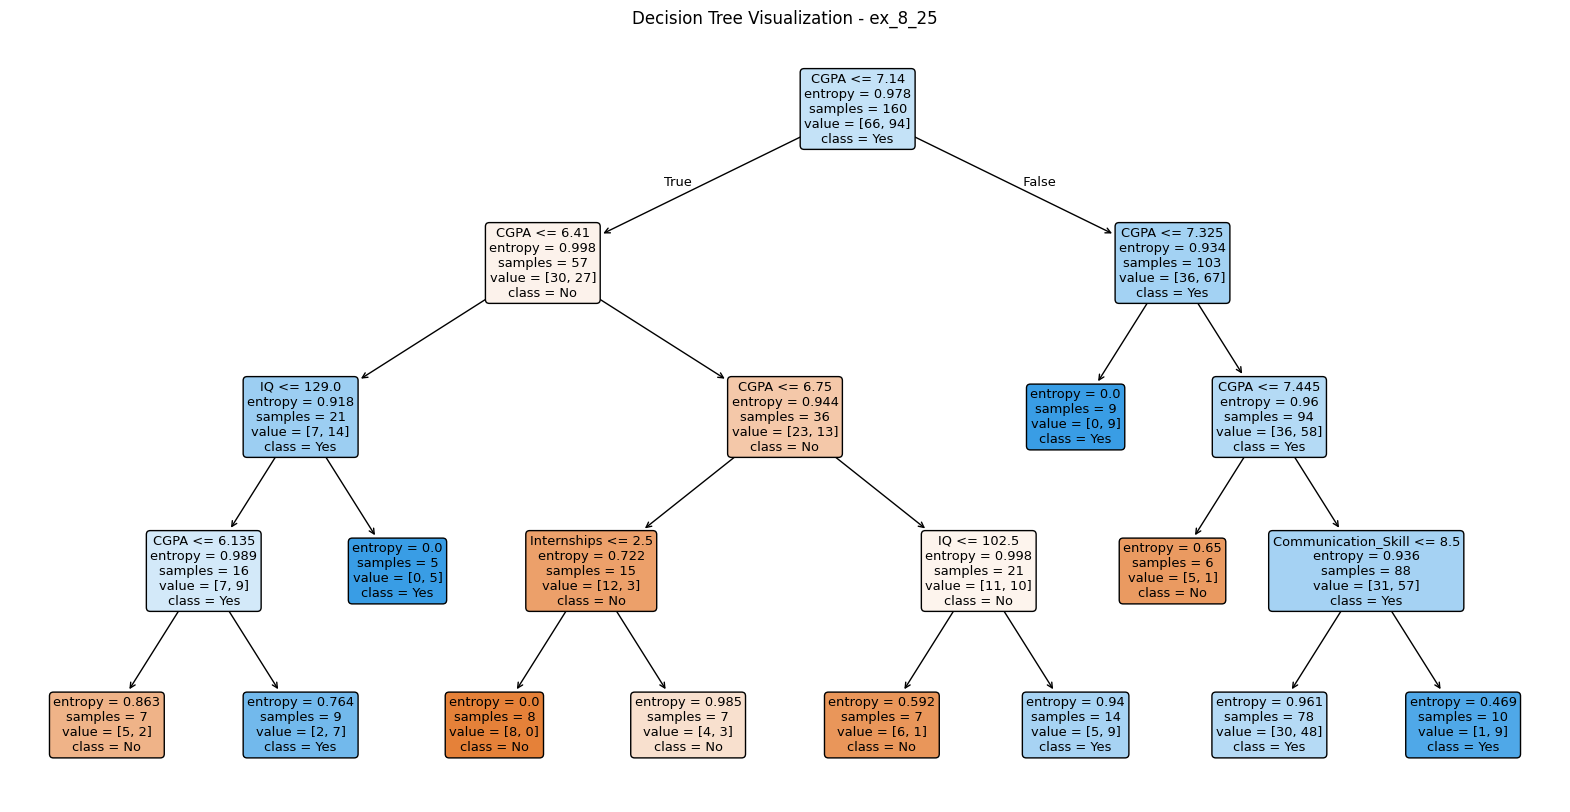

In [10]:
# ============================================================
# DECISION TREE CLASSIFICATION PROJECT (ex_8_25)
# Dataset: placement_dataset.csv
# Target Variable: Placed
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

# Dataset path in Google Drive
DATA_PATH = "/content/drive/MyDrive/Colab/placement_dataset.csv"

# Target column
TARGET_COL = "Placed"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

try:
    df = pd.read_csv(DATA_PATH)
except Exception as e:
    print(f"Error loading CSV: {e}")

print("=" * 60)
print("DECISION TREE CLASSIFICATION PROJECT - EX_8_25")
print("=" * 60)

print("\nDataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 5. DATA PREPROCESSING (Handling Missing & Categorical)
# ------------------------------------------------------------

# Separate Features and Target first
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Handle Missing Values for Numeric Columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
imputer = SimpleImputer(strategy="median")
X[num_cols] = imputer.fit_transform(X[num_cols])

# Handle Categorical Features (Branch) using One-Hot Encoding
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns, drop_first=True)

print("\nPreprocessing Complete: Missing values handled and categorical variables encoded.")


# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 7. MODEL TRAINING
# ------------------------------------------------------------

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 60)
print("TRAINING DECISION TREE MODEL")
print("=" * 60)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")


# ------------------------------------------------------------
# 8. EVALUATION
# ------------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE (ex_8_25 STYLE)")
print("=" * 60)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ------------------------------------------------------------
# 9. VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization - ex_8_25")
plt.show()